In [ ]:
# Load data

import sys
from pathlib import Path

# Path to the parent folder (where util.py is)
parent_path = Path().resolve().parent.parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import help_functions as hp


data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\Data.csv') 

data.head()

Slope per year: -0.10976278
Intercept: 220.14864275
p-value: 0.031126180967982475
R²: 0.19421959874808664


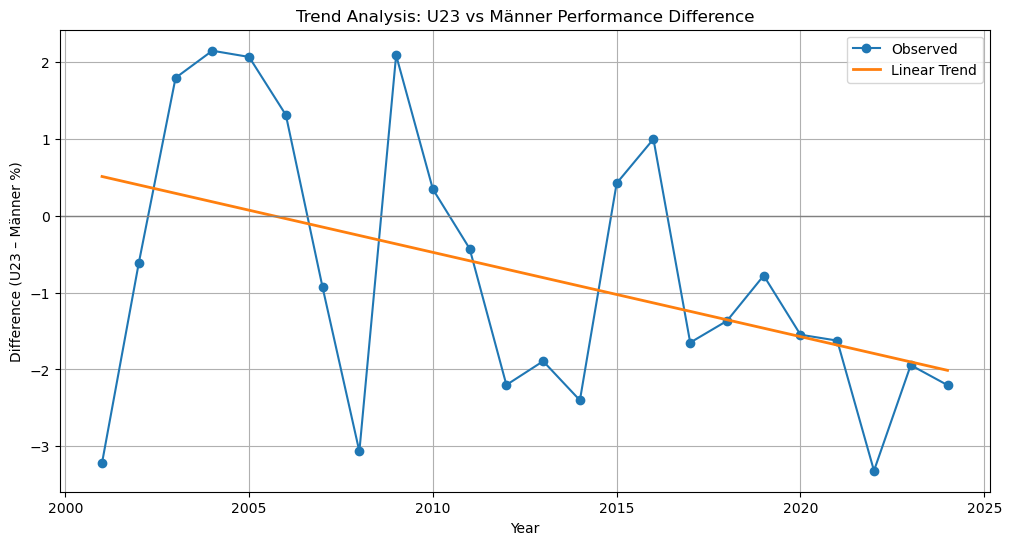

   year  predicted_difference
0  2025             -2.120987
1  2026             -2.230750
2  2027             -2.340512
3  2028             -2.450275
4  2029             -2.560038
5  2030             -2.669801


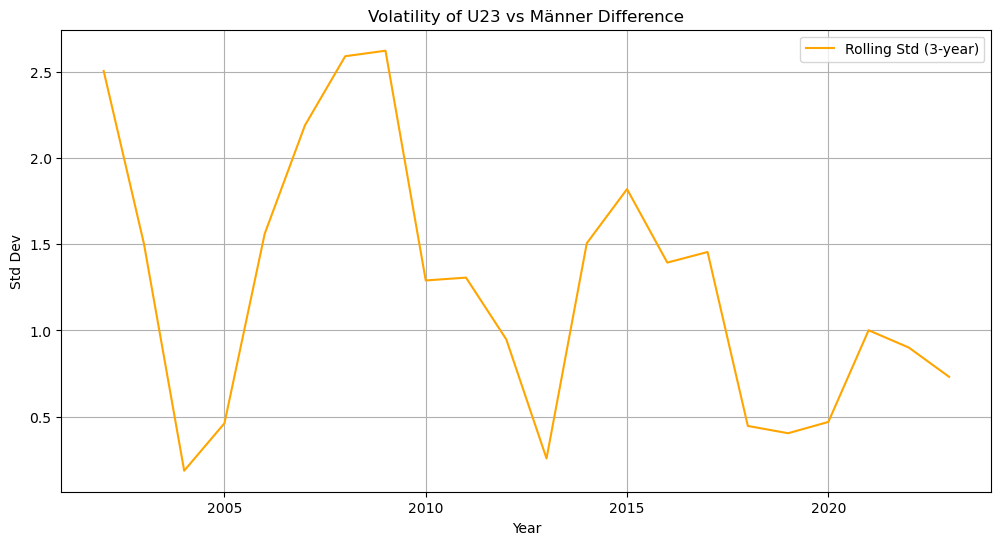

In [ ]:
import pandas as pd
import numpy as np

data = {
    2001:   -3.215554,
    2002:   -0.611855,
    2003:    1.797928,
    2004:    2.151379,
    2005:    2.070433,
    2006:    1.315789,
    2007:   -0.931736,
    2008:   -3.067485,
    2009:    2.093114,
    2010:    0.347826,
    2011:   -0.426109,
    2012:   -2.201317,
    2013:   -1.892094,
    2014:   -2.401050,
    2015:    0.425614,
    2016:    1.000962,
    2017:   -1.649602,
    2018:   -1.367262,
    2019:   -0.777001,
    2020:   -1.547389,
    2021:   -1.624084,
    2022:   -3.318541,
    2023:   -1.943288,
    2024:   -2.203526
}

df = pd.DataFrame.from_dict(data, orient="index", columns=["diff"])
df.index.name = "year"

from scipy.stats import linregress

res = linregress(df.index, df["diff"])

print("Slope per year:", res.slope)
print("Intercept:", res.intercept)
print("p-value:", res.pvalue)
print("R²:", res.rvalue**2)

import matplotlib.pyplot as plt
import numpy as np

years = df.index.values
pred = res.intercept + res.slope * years

plt.figure(figsize=(12,6))
plt.plot(df.index, df["diff"], marker="o", label="Observed")
plt.plot(df.index, pred, label="Linear Trend", linewidth=2)

plt.xlabel("Year")
plt.ylabel("Difference (U23 – Männer %)")
plt.title("Trend Analysis: U23 vs Männer Performance Difference")
plt.axhline(0, color="gray", linewidth=1)
plt.grid(True)
plt.legend()
plt.show()

future_years = np.arange(2025, 2031)
future_pred = res.intercept + res.slope * future_years

prediction_df = pd.DataFrame({
    "year": future_years,
    "predicted_difference": future_pred
})
print(prediction_df)

df["rolling_std"] = df["diff"].rolling(3, center=True).std()

plt.figure(figsize=(12,6))
plt.plot(df.index, df["rolling_std"], label="Rolling Std (3-year)", color="orange")
plt.title("Volatility of U23 vs Männer Difference")
plt.xlabel("Year")
plt.ylabel("Std Dev")
plt.grid(True)
plt.legend()
plt.show()
